In [37]:
#Inicialización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_semestral_bd = pd.read_excel('bd_matriculas.xlsx')

#Funciones

### Intervalos de Sturges
def calcular_intervalos_sturges(
    serie: pd.Series
) -> int:
    
    n = serie.dropna().size
    return round(1 + 3.3 * np.log10(n))

## Tabla de Frecuencia
def generar_tabla_frec(
    df_dataFrame: pd.DataFrame
) ->pd.DataFrame:
    
    tamanio = (df_dataFrame).size
    fi = df_dataFrame.value_counts().sort_index()
    Fi = fi.cumsum()
    hi = (fi/tamanio)*100
    Hi = (Fi/tamanio)*100

    df_frecuencias = pd.DataFrame({
        'FREC ABSOLUTA': fi,
        'FREC ABSOLUTA ACUM': Fi,
        'FREC RELATIVA': hi,
        'FREC RELATIVA ACUM': Hi
    })

    return round(df_frecuencias, 1)



## Tabla de Frecuencia para variables cuantitativas continuas
def generar_tabla_frec_continua(
    serie: pd.Series,
    intervalos: int,
    decimales: int = 0
) -> pd.DataFrame:
    
    serie = serie.dropna()
    n = serie.size

    clases = pd.cut(
        serie,
        bins=intervalos,
        include_lowest=True,
        precision=decimales
    )

    frecuencia = clases.value_counts(sort=False)

    tabla = pd.DataFrame({
        'FREC ABSOLUTA': frecuencia,
        'FREC ABSOLUTA ACUM': frecuencia.cumsum(),
        'FREC RELATIVA (%)': (frecuencia / n) * 100,
        'FREC RELATIVA ACUM (%)': ((frecuencia / n) * 100).cumsum()
    })

    return tabla.round(1)


## Gráfico Circular
def generar_grafico_circular(
    titulo: str,
    df_tf: pd.DataFrame
):
    
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_title(titulo)

    ax.pie(
        df_tf['FREC ABSOLUTA'],
        labels=df_tf.index,
        autopct='%.1f%%'
    )

    plt.show()



## Gráfico de Barras
def generar_grafico_barra(
    titulo: str,
    x_nombre: str,
    y_nombre: str,
    df_tf: pd.DataFrame,
    ancho: int = 10,
    alto: int = 6,
    top: int = None,
    separacion: float = 0.7
):
    
    df_grafico = df_tf.copy()

    # Seleccionar solo las primeras categorías
    if top is not None:
        df_grafico = df_grafico.sort_values(
            'FREC ABSOLUTA',
            ascending=False
        ).head(top)

    # Ordenar para que la mayor quede arriba
    df_grafico = df_grafico.sort_values(
        'FREC ABSOLUTA',
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(ancho, alto))

    ax.set_title(titulo)
    ax.set_xlabel(x_nombre)
    ax.set_ylabel(y_nombre)

    grafico_barra = ax.barh(
        df_grafico.index.astype(str),
        df_grafico['FREC ABSOLUTA'],
        height=separacion
    )

    ax.bar_label(grafico_barra, padding=3)

    plt.tight_layout()
    plt.show()



## Histograma
def generar_histograma(
    titulo: str,
    x_nombre: str,
    y_nombre: str,
    intervalos: int,
    variable: str,
    df: pd.DataFrame,
    ancho: int = 10,
    alto: int = 6
):
    
    fig, ax = plt.subplots(figsize=(ancho, alto))

    frecuencias, limites, barras = ax.hist(
        df[variable].dropna(),
        bins=intervalos,
        edgecolor='black'
    )

    ax.set_title(titulo)
    ax.set_xlabel(x_nombre)
    ax.set_ylabel(y_nombre)

    # Agregar frecuencia encima de cada barra
    ax.bar_label(
        barras,
        labels=[int(f) for f in frecuencias],
        padding=3
    )

    plt.tight_layout()
    plt.show()



## Medidas de Tendencia Central
def calcular_mtc(
    serie: pd.Series,
    decimales: int = 2
) -> pd.DataFrame:
    
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()

    df_mtc = pd.DataFrame({
        'MEDIA': [round(media, decimales)],
        'MEDIANA': [round(mediana, decimales)],
        'MODA': [round(moda.iloc[0], decimales)]
    })

    return df_mtc



## Percentiles
def calcular_percentiles(
    serie: pd.Series,
    percentiles: list,
    decimales: int = 2
) -> pd.DataFrame:

    valores = serie.quantile(
        [p / 100 for p in percentiles]
    )

    df_percentiles = pd.DataFrame({
        'PERCENTIL': percentiles,
        'VALOR': valores.values
    })

    df_percentiles['VALOR'] = df_percentiles['VALOR'].round(decimales)

    return df_percentiles



## Medidas de Dispersión
# ddof = 0 para población, ddof = 1 para muestra
def calcular_dispersion(
    serie: pd.Series,
    decimales: int = 2,
    ddof: int = 0
) -> pd.DataFrame:
    
    rango = serie.max() - serie.min()
    varianza = serie.var(ddof=ddof)
    desviacion = serie.std(ddof=ddof)

    df_dispersion = pd.DataFrame({
        'RANGO': [rango],
        'VARIANZA': [varianza],
        'DESVIACION ESTANDAR': [desviacion]
    })

    return df_dispersion.round(decimales)

MATRICULAS ED. SUPERIOR ÑUBLE 2021:

a. Identificar la población:

    Población Finita que corresponde al conjunto de estudiantes matriculados en instituciones de educación superior de la Región de Ñuble durante el año 2021.

b. Clasificar todas las variables:

    Rango Edad: Cualitativa Ordinal
    Edad......: Cuantitativa Discreta
    Género....: Cualitativa Nominal

    Semestre ingreso: Cualitativa Ordinal
    Año ingreso.....: Cuantitativa Discreta

    Nombre de Institución: Cualitativa Nominal
    Tipo de Institución..: Cualitativa Nominal

    Acreditación Institucional: Cualitativa Ordinal
    Periodo de Acreditación...: Cuantitativa Discreta
    Años de Acreditación......: Cuantitativa Discreta

    Area Conocimiento: Cualitativa Nominal
    Nombre Carrera...: Cualitativa Nominal

    Requisito Ingreso: Cualitativa Nominal
    Via de Ingreso...: Cualitativa Nominal

    Tipo Plan Carrera: Cualitativa Nominal
    Modalidad........: Cualitativa Nominal
    Jornada..........: Cualitativa Nominal

    Nivel de Estudio Carrera: Cualitativa Ordinal
    Nivel Carrera...........: Cualitativa Ordinal

    Duración Proceso Titulación: Cuantitativa Discreta
    Duración Plan de Estudio...: Cuantitativa Discreta
    Duración Total Carrera.....: Cuantitativa Discreta

    Valor Matricula: Cuantitativa Continua
    Valor Arancel..: Cuantitativa Continua

    Provincia Sede.: Cualitativa Nominal
    Región Sede....: Cualitativa Nominal
    Comuna Sede....: Cualitativa Nominal

c. Escoger 6 variables a trabajar (3 cuantitativas, dos continuas y una discreta; y 3 cualitativas a elección, entre ellas dos nominales y una ordinal):

    Cualitativas:
        Nominal - Area Conocimiento
        Nominal - Nombre Carrera
        Ordinal - Nivel de Estudio Carrera
        
    Cuantitativas:
        Discreta - Edad
        Continua - Valor Matricula
        Continua - Valor Arancel

d. Tablas de frecuencia:

In [38]:
df_tf_ac = generar_tabla_frec(
    df_semestral_bd['AREA CONOCIMIENTO']
)

df_tf_nc = generar_tabla_frec(
    df_semestral_bd['NOMBRE CARRERA']
)

df_tf_ndec = generar_tabla_frec(
    df_semestral_bd['NIVEL DE ESTUDIO CARRERA']
)

df_tf_edad = generar_tabla_frec(
    df_semestral_bd['EDAD']
)



k_vm = calcular_intervalos_sturges(
    df_semestral_bd['VALOR MATRICULA (PESOS)']
)

k_va = calcular_intervalos_sturges(
    df_semestral_bd['VALOR ARANCEL (PESOS)']
)

df_tf_vm = generar_tabla_frec_continua(
    df_semestral_bd['VALOR MATRICULA (PESOS)'],
    k_vm
)

df_tf_va = generar_tabla_frec_continua(
    df_semestral_bd['VALOR ARANCEL (PESOS)'],
    k_va
)

e. Gráficos:

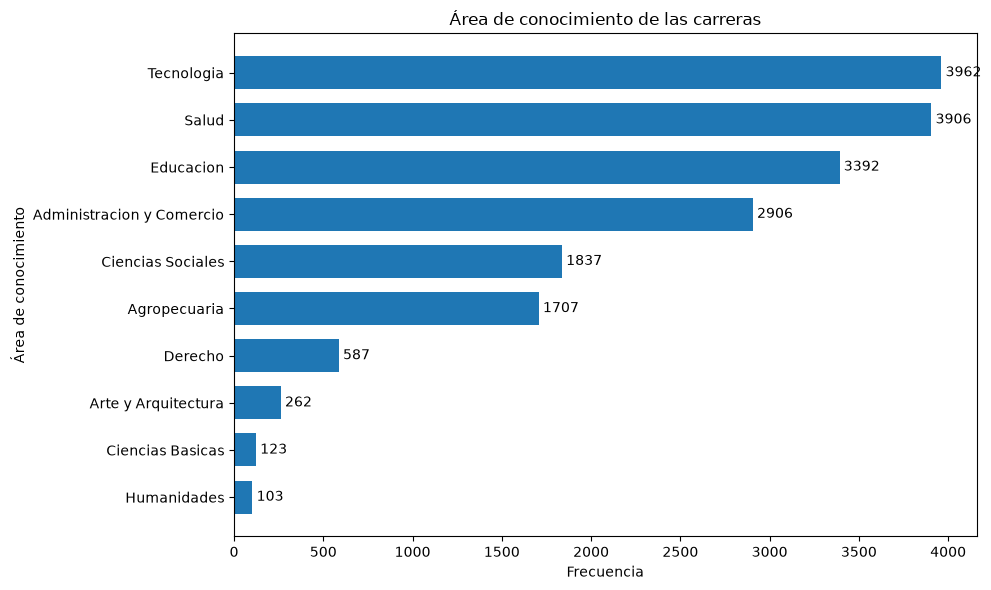

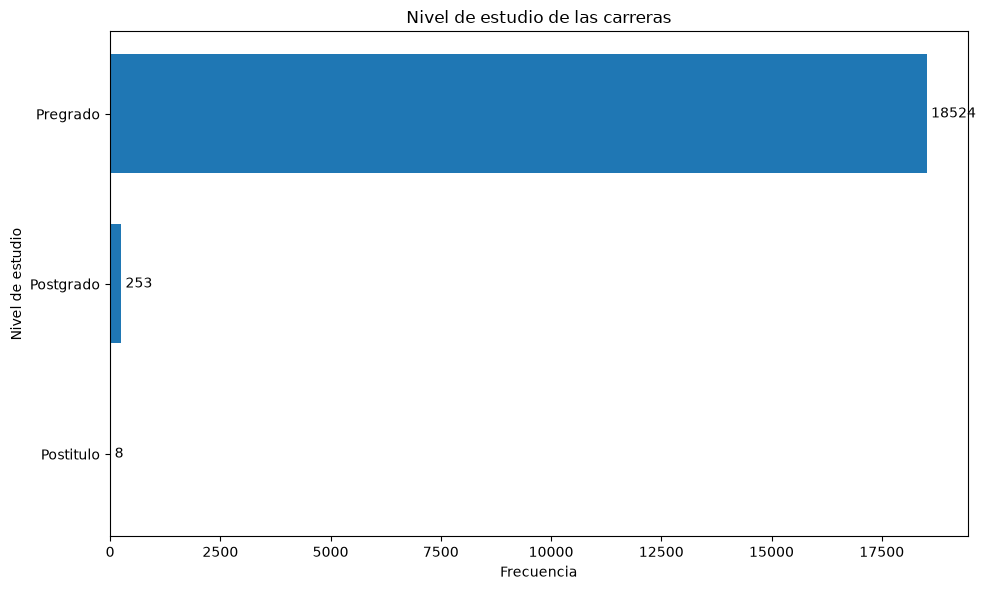

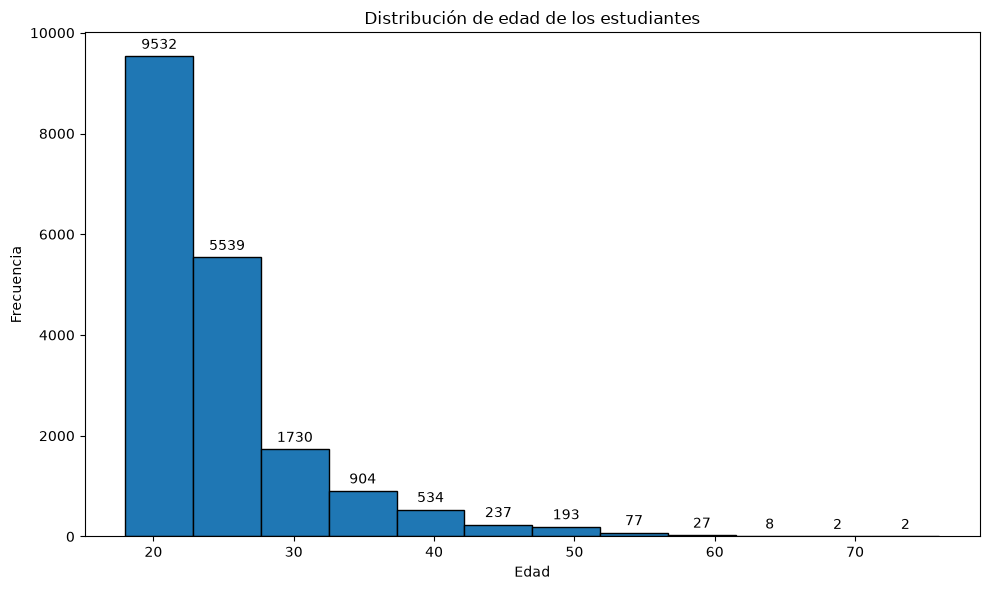

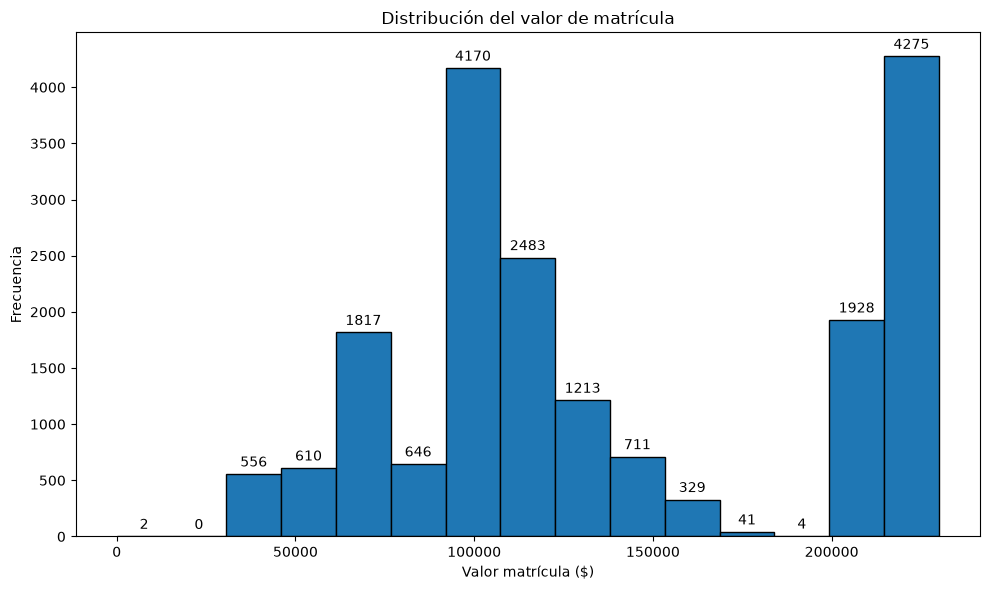

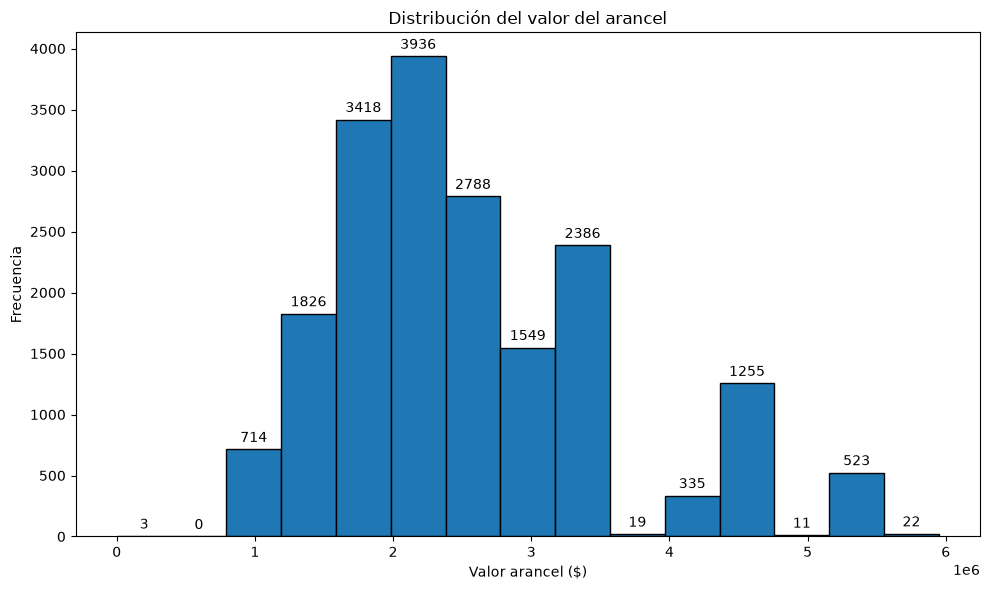

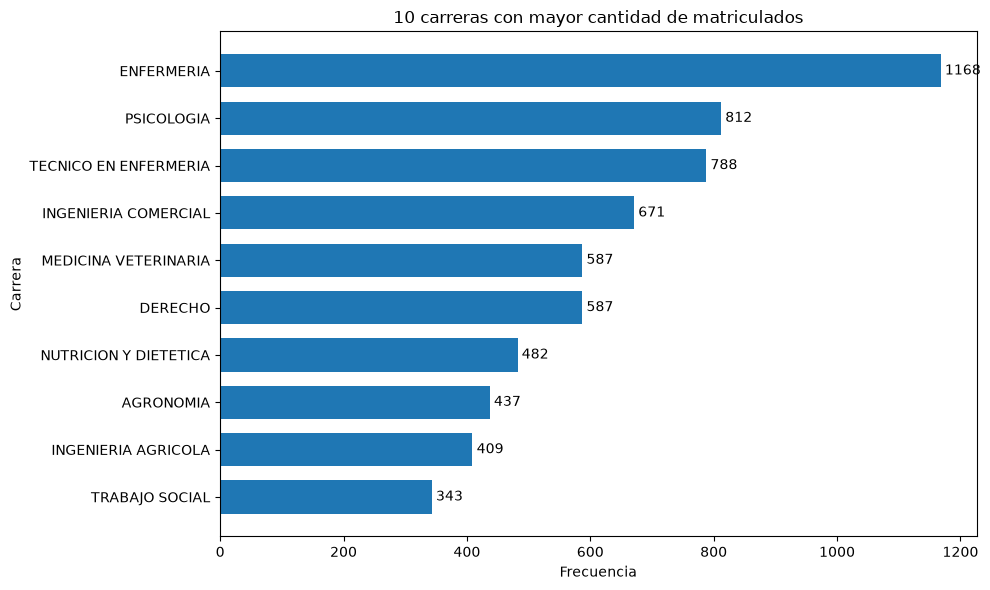

In [39]:
generar_grafico_barra(
    'Área de conocimiento de las carreras',
    'Frecuencia',
    'Área de conocimiento',
    df_tf_ac
)

generar_grafico_barra(
    'Nivel de estudio de las carreras',
    'Frecuencia',
    'Nivel de estudio',
    df_tf_ndec
)

generar_histograma(
    'Distribución de edad de los estudiantes',
    'Edad',
    'Frecuencia',
    12,
    'EDAD',
    df_semestral_bd
)

generar_histograma(
    'Distribución del valor de matrícula',
    'Valor matrícula ($)',
    'Frecuencia',
    k_vm,
    'VALOR MATRICULA (PESOS)',
    df_semestral_bd
)

generar_histograma(
    'Distribución del valor del arancel',
    'Valor arancel ($)',
    'Frecuencia',
    k_va,
    'VALOR ARANCEL (PESOS)',
    df_semestral_bd
)

generar_grafico_barra(
    '10 carreras con mayor cantidad de matriculados',
    'Frecuencia',
    'Carrera',
    df_tf_nc,
    top=10
)

f. Medidas de tendencia central (solo cuantitativa)

In [40]:
mtc_edad = calcular_mtc(
    df_semestral_bd['EDAD'],
    decimales=0
)

mtc_matricula = calcular_mtc(
    df_semestral_bd['VALOR MATRICULA (PESOS)']
)

mtc_arancel = calcular_mtc(
    df_semestral_bd['VALOR ARANCEL (PESOS)']
)

print('EDAD')
display(mtc_edad)

print('VALOR MATRÍCULA')
display(mtc_matricula)

print('VALOR ARANCEL')
display(mtc_arancel)

EDAD


,MEDIA,MEDIANA,MODA
0,24.0,22.0,19


VALOR MATRÍCULA


,MEDIA,MEDIANA,MODA
0,138816.83,120000.0,220000


VALOR ARANCEL


,MEDIA,MEDIANA,MODA
0,2546537.72,2238000.0,2489000


g. Percentiles (solo cuantitativa)

In [41]:
percentiles_edad = calcular_percentiles(
    df_semestral_bd['EDAD'],
    [25, 50, 75],
    decimales=0
)

percentiles_matricula = calcular_percentiles(
    df_semestral_bd['VALOR MATRICULA (PESOS)'],
    [25, 50, 75]
)

percentiles_arancel = calcular_percentiles(
    df_semestral_bd['VALOR ARANCEL (PESOS)'],
    [25, 50, 75]
)

print('PERCENTILES EDAD')
display(percentiles_edad)

print('PERCENTILES MATRÍCULA')
display(percentiles_matricula)

print('PERCENTILES ARANCEL')
display(percentiles_arancel)

PERCENTILES EDAD


,PERCENTIL,VALOR
0,25,20.0
1,50,22.0
2,75,26.0


PERCENTILES MATRÍCULA


,PERCENTIL,VALOR
0,25,105000.0
1,50,120000.0
2,75,200000.0


PERCENTILES ARANCEL


,PERCENTIL,VALOR
0,25,1865000.0
1,50,2238000.0
2,75,3161000.0


h. Medidas de Dispersión

In [42]:
dispersion_edad = calcular_dispersion(
    df_semestral_bd['EDAD']
)

dispersion_matricula = calcular_dispersion(
    df_semestral_bd['VALOR MATRICULA (PESOS)']
)

dispersion_arancel = calcular_dispersion(
    df_semestral_bd['VALOR ARANCEL (PESOS)']
)

print('DISPERSIÓN EDAD')
display(dispersion_edad)

print('DISPERSIÓN MATRÍCULA')
display(dispersion_matricula)

print('DISPERSIÓN ARANCEL')
display(dispersion_arancel)

DISPERSIÓN EDAD


,RANGO,VARIANZA,DESVIACION ESTANDAR
0,58,41.99,6.48


DISPERSIÓN MATRÍCULA


,RANGO,VARIANZA,DESVIACION ESTANDAR
0,230000,3.335902e+09,57757.27


DISPERSIÓN ARANCEL


,RANGO,VARIANZA,DESVIACION ESTANDAR
0,5950000,1.038994e+12,1019310.36


# Comentarios y análisis descriptivo

---

## ITEM I

### 1. Área de conocimiento
**Tipo de variable: Cualitativa nominal**

La distribución de los estudiantes según el área de conocimiento permite observar que la matrícula no se distribuye de manera uniforme entre todas las áreas. Algunas concentran una mayor cantidad de estudiantes, mientras que otras presentan una participación considerablemente menor.

El gráfico permite identificar las áreas con mayor presencia dentro del conjunto de datos y comparar visualmente la participación de cada categoría.

---

### 2. Nombre de carrera
**Tipo de variable: Cualitativa nominal**

La variable presenta una gran diversidad de carreras, por lo que representar todas las categorías en un único gráfico dificultaría su interpretación.

Por este motivo, se utilizó un gráfico **TOP 10**, que permite identificar las diez carreras con mayor cantidad de matriculados y facilita la comparación entre ellas.

Este análisis permite observar cuáles son las carreras que concentran una mayor cantidad de estudiantes dentro de la matrícula analizada.

---

### 3. Nivel de estudio de carrera
**Tipo de variable: Cualitativa ordinal**

La distribución del nivel de estudio permite observar cómo se concentra la matrícula entre los distintos niveles académicos.

Al tratarse de una variable ordinal, sus categorías presentan un orden, lo que permite comparar la participación de los diferentes niveles de estudio y determinar cuáles concentran una mayor cantidad de estudiantes.

---

### 4. Edad
**Tipo de variable: Cuantitativa discreta**

#### Medidas de tendencia central

La edad promedio de los estudiantes es de aproximadamente **24 años**, mientras que la mediana corresponde a **22 años** y la moda a **19 años**.

La media es superior a la mediana, lo que indica que la presencia de estudiantes de mayor edad influye en el promedio. Por otra parte, la moda de 19 años muestra que esta es la edad que se presenta con mayor frecuencia.

En general, las medidas de tendencia central indican una concentración importante de estudiantes jóvenes.

#### Percentiles

El **25 %** de los estudiantes tiene una edad de hasta **20 años**, el **50 %** tiene hasta **22 años** y el **75 %** tiene hasta **26 años**.

Por lo tanto, el **50 % central de los estudiantes se encuentra entre los 20 y 26 años**, lo que confirma que la matrícula está principalmente concentrada en edades jóvenes.

#### Medidas de dispersión

El rango permite conocer la diferencia entre la edad mínima y máxima registrada, mientras que la varianza y la desviación estándar permiten medir cuánto se dispersan las edades respecto de su promedio.

En conjunto, estas medidas permiten complementar las medidas de tendencia central y observar que, aunque existe una concentración importante en edades jóvenes, también se encuentran estudiantes de edades considerablemente mayores.

#### Histograma

El histograma muestra una mayor concentración de estudiantes en las edades jóvenes. A medida que aumenta la edad, la frecuencia disminuye progresivamente.

Esto es coherente con los resultados obtenidos mediante las medidas de tendencia central y los percentiles.

---

### 5. Valor de matrícula
**Tipo de variable: Cuantitativa continua**

#### Medidas de tendencia central

El valor promedio de matrícula es de aproximadamente **$138.817**, mientras que la mediana corresponde a **$120.000** y la moda a **$220.000**.

La media es superior a la mediana, lo que indica que la presencia de valores de matrícula elevados aumenta el promedio.

La diferencia entre estas medidas muestra que el valor típico de matrícula se encuentra por debajo del promedio general.

#### Percentiles

El **25 %** de las matrículas presenta un valor de hasta **$105.000**, el **50 %** hasta **$120.000** y el **75 %** hasta **$200.000**.

Esto significa que la mitad central de los valores se encuentra entre **$105.000 y $200.000**, evidenciando una concentración importante de las matrículas en valores bajos y medios.

#### Medidas de dispersión

La desviación estándar obtenida indica cuánto se alejan, en promedio, los valores de matrícula respecto del valor promedio de matrícula. Junto con el rango, permite observar la variabilidad existente entre los valores de matrícula.

#### Histograma

El histograma muestra una concentración de matrículas en los valores más bajos, mientras que los valores elevados presentan una frecuencia menor.

La distribución presenta una extensión hacia valores superiores, lo que es consistente con la diferencia observada entre la media y la mediana.

---

### 6. Valor de arancel
**Tipo de variable: Cuantitativa continua**

#### Medidas de tendencia central

El arancel promedio es de aproximadamente **$2.546.538**, mientras que la mediana corresponde a **$2.238.000** y la moda a **$2.489.000**.

La media es superior a la mediana, lo que indica que los aranceles de valores elevados tienen influencia sobre el promedio general.

Por lo tanto, el promedio resulta mayor que el valor central de la distribución debido a la presencia de aranceles relativamente altos.

#### Percentiles

El **25 %** de los aranceles presenta un valor de hasta **$1.865.000**, el **50 %** hasta **$2.238.000** y el **75 %** hasta **$3.161.000**.

En consecuencia, el **50 % central de los aranceles se encuentra entre $1.865.000 y $3.161.000**.

Esto muestra una distribución con diferencias importantes entre los valores más bajos y los más altos.

#### Medidas de dispersión

Las medidas de dispersión permiten observar la variabilidad existente entre los aranceles de las distintas carreras.

El rango evidencia una diferencia considerable entre los valores mínimo y máximo, mientras que la varianza y la desviación estándar permiten cuantificar la dispersión de los datos respecto del promedio.

Esta variabilidad es consistente con la existencia de carreras cuyos aranceles son considerablemente superiores a los valores centrales de la distribución.

#### Histograma

El histograma muestra una concentración importante de aranceles en los valores bajos y medios, junto con una extensión hacia valores más elevados.

Esta distribución hacia la derecha es consistente con la diferencia existente entre la media y la mediana.

---

## ITEM II

### 1. ¿Hay áreas del conocimiento donde las carreras sean más caras?

Para responder esta pregunta se compararon los **aranceles según el área de conocimiento**, utilizando principalmente la mediana como medida de comparación.

La mediana resulta útil en este caso porque permite comparar los valores centrales de cada área reduciendo la influencia que podrían tener valores extremadamente altos o bajos.

Los resultados muestran diferencias entre las áreas de conocimiento. **Agropecuaria** y **Derecho** presentan las mayores medianas, con valores aproximados de **$4.751.078** y **$4.713.138**, respectivamente. En contraste, **Educación** presenta una mediana cercana a **$2.282.000**.

Por lo tanto, según la mediana del arancel, **Agropecuaria y Derecho** son las áreas que presentan los valores centrales más elevados.

In [43]:
arancel_area = df_semestral_bd.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].agg(
    MEDIA='mean',
    MEDIANA='median'
).sort_values('MEDIANA', ascending=False)

display(arancel_area)

,MEDIA,MEDIANA
AREA CONOCIMIENTO,,
Agropecuaria,3.702404e+06,4751078.0
Derecho,3.804416e+06,4713138.0
Arte y Arquitectura,2.839874e+06,3161000.0
Salud,2.730533e+06,2865000.0
Humanidades,2.497373e+06,2800000.0
Ciencias Sociales,2.360218e+06,2595000.0
Educacion,2.003612e+06,2282000.0
Tecnologia,2.395887e+06,2146000.0
Administracion y Comercio,2.309842e+06,2020000.0



---

### 2. ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

Para analizar esta relación se comparó la **edad promedio de los estudiantes según el tipo de institución**.

Los resultados obtenidos fueron:

- **Universidades CRUCH:** 23,1 años.
- **CFT:** 23,7 años.
- **Universidades Privadas:** 25,2 años.
- **Institutos Profesionales:** 26,2 años.

Las **Universidades CRUCH presentan la menor edad promedio**, mientras que los **Institutos Profesionales presentan la mayor**.

Esto sugiere que existe una diferencia en la edad promedio de los estudiantes según el tipo de institución. Los estudiantes de las Universidades CRUCH tienden a ser más jóvenes, mientras que en los Institutos Profesionales y Universidades Privadas se observa una mayor edad promedio.

Sin embargo, estos resultados **no permiten afirmar que la edad determine el tipo de institución**, ya que existen estudiantes de diferentes edades en todas las categorías.

TIPO DE INSTITUCION
Institutos Profesionales        26.192589
Universidades Privadas          25.243512
Centros de Formacion Tecnica    23.653846
Universidades CRUCH             23.106474
Name: EDAD, dtype: float64

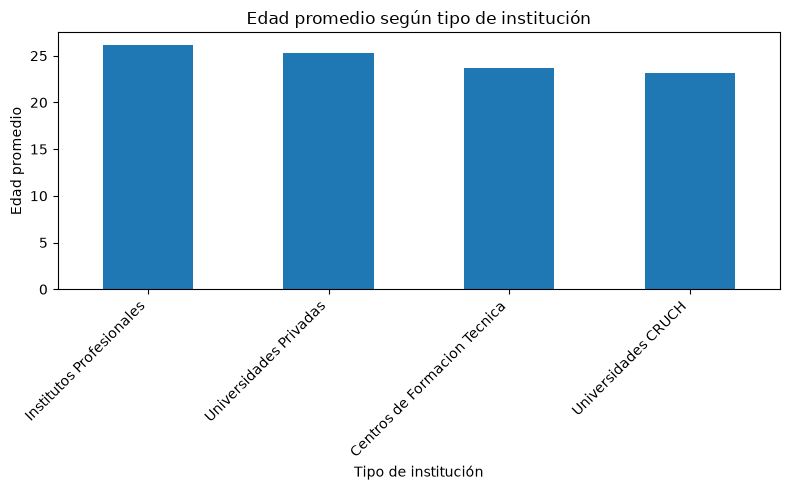

In [44]:
# Calcular la edad promedio según tipo de institución
edad_institucion = (
    df_semestral_bd.groupby('TIPO DE INSTITUCION')['EDAD']
    .mean()
    .sort_values(ascending=False)
)

display(edad_institucion)

# Gráfico de edad promedio por tipo de institución
edad_institucion.plot(
    kind='bar',
    figsize=(8, 5),
    title='Edad promedio según tipo de institución',
    xlabel='Tipo de institución',
    ylabel='Edad promedio'
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


---

### 3. ¿Hay carreras cuyo arancel sea sustantivamente más caro que la mayoría de los aranceles? ¿Qué explicación pueden encontrar?

Sí. Al comparar los aranceles de las distintas carreras se identifican algunas cuyos valores se encuentran considerablemente por encima de los valores centrales de la distribución.

Entre ellas destacan:

- **Odontología:** aproximadamente **$5.950.000**.
- **Medicina Veterinaria:** aproximadamente **$5.049.000**.
- **Ingeniería Ambiental:** aproximadamente **$4.747.000**.

Una posible explicación es que determinadas carreras requieren mayores niveles de **infraestructura, equipamiento especializado, laboratorios, materiales y recursos técnicos**, lo que puede incrementar sus costos de formación.

También debe considerarse la duración de las carreras. Por ejemplo, **Odontología tiene una duración total de 12 semestres**, mientras que **Medicina Veterinaria tiene una duración de 11 semestres**.

En el contexto de Ñuble, además, las características productivas de la región permiten contextualizar la presencia de carreras relacionadas con el ámbito **agropecuario y silvoagropecuario**, como Medicina Veterinaria, Agronomía e ingenierías vinculadas al sector.

Por lo tanto, los aranceles elevados pueden estar relacionados con factores como el **área de formación, los recursos necesarios para impartir la carrera y su duración**, además de las características particulares de cada institución y programa.

In [45]:
# Calcular el arancel promedio por carrera
arancel_carrera = (
    df_semestral_bd.groupby('NOMBRE CARRERA')['VALOR ARANCEL (PESOS)']
    .mean()
    .sort_values(ascending=False)
)

# Mediana general de los aranceles
mediana_general = df_semestral_bd['VALOR ARANCEL (PESOS)'].median()

print(f"Mediana general de arancel: ${mediana_general:,.0f}")
print("\n10 carreras con mayor arancel promedio:")
display(arancel_carrera.head(10))

# Obtener duración promedio de las carreras con mayor arancel
duracion_carrera = (
    df_semestral_bd.groupby('NOMBRE CARRERA')['DURACION TOTAL CARRERA (SEMESTRES)']
    .mean()
)

analisis_carreras = pd.DataFrame({
    'ARANCEL PROMEDIO': arancel_carrera,
    'DURACION PROMEDIO (SEMESTRES)': duracion_carrera
})

print("Duración promedio de las carreras con mayor arancel")
display(analisis_carreras.head(10))

Mediana general de arancel: $2,238,000

10 carreras con mayor arancel promedio:


NOMBRE CARRERA
ODONTOLOGIA                              5.950000e+06
MEDICINA VETERINARIA                     5.048597e+06
INGENIERIA AMBIENTAL                     4.746721e+06
INGENIERIA CIVIL AGRICOLA                4.599277e+06
AGRONOMIA                                4.580743e+06
INGENIERIA AGROINDUSTRIAL                4.569069e+06
DOCTORADO EN CIENCIAS DE LA AGRONOMIA    4.128000e+06
DOCTORADO EN CIENCIAS VETERINARIAS       4.077000e+06
DERECHO                                  3.804416e+06
MAGISTER EN GESTION DE EMPRESAS          3.700000e+06
Name: VALOR ARANCEL (PESOS), dtype: float64

Duración promedio de las carreras con mayor arancel


,ARANCEL PROMEDIO,DURACION PROMEDIO (SEMESTRES)
NOMBRE CARRERA,,
ADMINISTRACION DE EMPRESAS,2.008000e+06,4.000000
ADMINISTRACION GASTRONOMICA INTERNACIONAL,2.212000e+06,8.000000
ADMINISTRACION TURISTICA INTERNACIONAL,1.942000e+06,8.000000
AGRONOMIA,4.580743e+06,10.000000
ANALISTA PROGRAMADOR,1.987370e+06,4.629921
AUDITORIA,1.670000e+06,8.000000
AUTOMATIZACION Y CONTROL INDUSTRIAL,2.122000e+06,4.000000
BACHILLERATO EN CIENCIAS,2.647000e+06,4.000000
BIBLIOTECOLOGIA DISTANCIA,9.000000e+05,5.000000
